# Introduction to word embedding


# dependency installation

In [5]:
! pip install spacy

ERROR: THESE PACKAGES DO NOT MATCH THE HASHES FROM THE REQUIREMENTS FILE. If you have updated the package versions, please update the hashes. Otherwise, examine the package contents carefully; someone may have tampered with them.
    unknown package:
        Expected sha256 9def18c76a4472b326cb91a195623c9ca38a2b86999ad2df9e00b49ba8c63734
             Got        2dfc5dbccc55640a7e989a199f692a52d9f4b0b41697830cfdc81bc5c70431b6



  Using cached spacy-3.8.14-cp312-cp312-win_amd64.whl.metadata (28 kB)
   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   ----------------

In [7]:
import os
import csv
import spacy



# class creation


In [11]:
class Corpus(object):
    def __init__(self, filename):
        self.filename = filename
        self.nlp = spacy.blank("en")

    def __iter__(self):
        with open(self.filename, "r") as i:
            reader = csv.reader(i, delimiter=",")
            for _, abstract in reader:
                tokens = [t.text.lower() for t in self.nlp(abstract)]
                yield tokens

documents = Corpus("D:/AgenticAI/arxiv.csv")

# individual tokens 

In [14]:
documents = list(documents)
documents[:10]

[['this',
  'paper',
  'investigates',
  'a',
  'cross',
  '-',
  'lingual',
  'document',
  'embedding',
  'method',
  'that',
  '\n',
  'improves',
  'the',
  'current',
  'neural',
  'machine',
  'translation',
  'framework',
  'based',
  'document',
  'vector',
  '\n',
  '(',
  'ntdv',
  'or',
  'simply',
  'nv',
  ')',
  '.',
  'nv',
  'is',
  'developed',
  'with',
  'a',
  'self',
  '-',
  'attention',
  'mechanism',
  'under',
  'the',
  '\n',
  'neural',
  'machine',
  'translation',
  '(',
  'nmt',
  ')',
  'framework',
  '.',
  'in',
  'nv',
  ',',
  'each',
  'pair',
  'of',
  'parallel',
  '\n',
  'documents',
  'in',
  'different',
  'languages',
  'are',
  'projected',
  'to',
  'the',
  'same',
  'shared',
  'layer',
  'in',
  'the',
  '\n',
  'model',
  '.',
  'however',
  ',',
  'the',
  'pair',
  'of',
  'nv',
  'embeddings',
  'are',
  'not',
  'guaranteed',
  'to',
  'be',
  'similar',
  '.',
  '\n',
  'this',
  'paper',
  'further',
  'adds',
  'a',
  'distance',


# import library

In [15]:
! pip install spacy gensim

# vectorization
### giving vectors a specfic value to each token 

In [27]:
import gensim
model = gensim.models.Word2Vec(documents, min_count=100, window=5, vector_size=100)

### to display specific vector for the token(any word),to find similar words we can go with this 

In [28]:
model.wv["nlp"]

array([ 1.5787655e-02, -1.8826231e-02,  1.2955874e+00, -8.7287295e-01,
       -4.3535009e-01, -2.7094206e-01,  9.9052846e-01, -4.2518586e-01,
        1.2445036e-02,  2.2129846e+00,  1.2136394e+00, -2.1214793e+00,
        1.9530303e+00,  7.4292994e-01, -5.7638717e-01, -3.5239622e-02,
       -4.2759061e-01,  1.6658463e+00, -5.6629241e-01,  2.2755539e+00,
       -3.2675898e-01, -2.4789719e-01, -1.7401943e-01,  8.3246148e-01,
       -8.4283763e-01, -1.2618147e+00,  2.3267310e+00,  7.7266198e-01,
        1.7111288e+00,  6.5744358e-01,  5.4593092e-01, -1.0931087e-01,
       -3.6034730e-01,  1.1464109e+00,  2.6323044e-01, -4.7898161e-01,
        1.0938046e+00, -3.5134084e+00,  6.3964844e-01,  2.7212291e+00,
       -1.6826428e+00, -2.2855453e+00,  3.2989860e+00,  5.5107743e-01,
       -1.6594737e+00,  9.1057844e-02,  2.1254737e+00,  6.9936764e-01,
        2.4120839e-01, -2.6144853e+00,  8.3839929e-01,  2.4828334e+00,
       -7.0574224e-01, -5.7682682e-02,  4.9100444e-01,  6.5405160e-01,
      

### similar tokens-vector 


In [29]:
print(model.wv.similarity("use","can"))

-0.023967333


### execute similar word 

In [30]:
print(model.wv.similar_by_word("can",topn=5))

[('could', 0.9195895195007324), ('may', 0.8057048320770264), ('will', 0.7902235388755798), ('might', 0.7861291766166687), ('should', 0.778512716293335)]


### most  similar word execute

In [31]:
print(model.wv.most_similar(positive=["could","will"],negative=["use"],topn=5))

[('should', 0.8099445700645447), ('might', 0.8004218339920044), ('would', 0.7967124581336975), ('can', 0.7928525805473328), ('may', 0.7781774401664734)]


### to execute only a word

In [38]:
print(model.wv.most_similar(positive=["can"],topn=10))

[('could', 0.9195895195007324), ('may', 0.8057048320770264), ('will', 0.7902235388755798), ('might', 0.7861291766166687), ('should', 0.778512716293335), ('must', 0.7637710571289062), ('would', 0.7620865702629089), ('needs', 0.545143187046051), ('helps', 0.5450955629348755), ('seems', 0.5284398794174194)]


In [36]:
print(model.wv.most_similar(positive=["tree"],topn=10))

[('trees', 0.7915142774581909), ('constituency', 0.7174925804138184), ('parse', 0.6680797338485718), ('recursive', 0.6593395471572876), ('dependency', 0.6290269494056702), ('constituent', 0.6160420179367065), ('path', 0.5939733386039734), ('parser', 0.5893433094024658), ('grammars', 0.586121678352356), ('syntax', 0.584052324295044)]


In [39]:
print(model.wv.doesnt_match("lstm cnn gru svm transformer".split())) # identified the word that does not match the others in the list ["lstm", "cnn", "gru", "svm", "transformer"] based on their vector embeddings in the trained Word2Vec model, and printed the result.
print(model.wv.doesnt_match("bert word2vec gpt-2 roberta xlnet".split()))
print(model.wv.doesnt_match("word2vec bert glove fasttext elmo".split()))

svm
word2vec
bert


# plotting embedding


In [44]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

target_word = "can"
selected_words = [w[0] for w in model.wv.most_similar(positive=[target_word], topn=200)] + [target_word]
embeddings = [model.wv[w] for w in selected_words] + model.wv["bert"]

mapped_embeddings = TSNE(n_components=2, metric='cosine', init='pca').fit_transform(embeddings)

### word cloud creation
### close to each other-similar and viceversa 

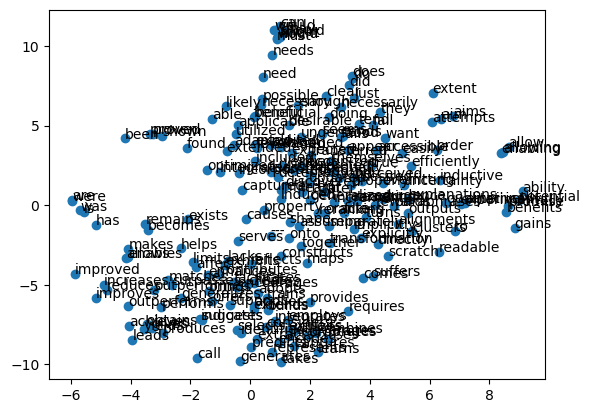

In [47]:
plt.Figure(figsize=(20, 20))
x = mapped_embeddings[:, 0]
y = mapped_embeddings[:, 1]
plt.scatter(x, y)

for i, txt in enumerate(selected_words):
    plt.annotate(txt, (x[i], y[i])) # created a scatter plot of the mapped embeddings, and annotated each point with the corresponding word from the list of selected words.
plt.show()